In [1]:
from mpc_python.cvxpy_mpc.utils import compute_path_from_wp, get_nn_idx, get_ref_trajectory
import numpy as np


In [2]:

# define track
wp_x = np.array([0, 3, 4, 6, 10, 11, 12, 6, 1, 0])
wp_y = np.array([0, 0, 2, 4, 3, 3, -1, -6, -2, -2])
wp_x = np.array([0, 5, 6, 10, 11, 15])
wp_y = np.array([0, 0, 2, 2, 0, 4])

track = compute_path_from_wp(wp_x, wp_y, step=0.1)
# vehicle state
state = [3.5, 0.5, 0, np.radians(30)]

# given vehicle pos find lookahead waypoints
nn_idx = (
    get_nn_idx(state, track) - 1
)


xref = get_ref_trajectory(state, track, 1.0, 4, 0.2, False)
# xref, _ = get_ref_trajectory2(state, track, 1.0)

# print(xref)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


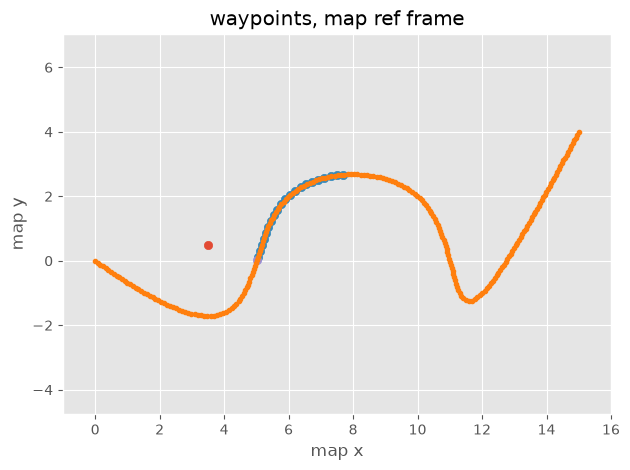

In [3]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

x = np.arange(-1, 2, 0.001)  # interp range of curve

# VEHICLE REF FRAME
# plt.subplot(2, 1, 1)
# plt.title("parametrized curve, vehicle ref frame")
# plt.scatter(0, 0)
# plt.scatter(wp_vehicle_frame[0, :], wp_vehicle_frame[1, :])
# plt.plot(x, [f(xs, coeff) for xs in x])
# plt.axis("equal")

# MAP REF FRAME
plt.title("waypoints, map ref frame")
plt.plot(
            track[0, :],
            track[1, :],
            c="tab:orange",
            marker=".",
            label="reference track",
        )
plt.scatter(state[0], state[1])
plt.scatter(xref[0], xref[1])
plt.scatter(track[0, nn_idx], track[1, nn_idx])
# plt.scatter(track[0, :], track[1, :])
# plt.scatter(track[0, nn_idx: nn_idx + LOOKAHED], track[1, nn_idx: nn_idx + LOOKAHED])
plt.axis("equal")

plt.xlabel("map x")
plt.ylabel("map y")

x_pad, y_pad = 1.0, 1.0
plt.xlim(
   track[0, :].min() - x_pad, track[0, :].max() + x_pad
)
plt.ylim(
    track[1, :].min() - y_pad, track[1, :].max() + y_pad
)
plt.tight_layout()
plt.show()
# plt.savefig("fitted_poly")